# Monte-Carlo Markov Chain

This is a class of stochastic methods which draw samples from a probability distribution.

Say we want to compute expectations over some complicated distribution $\mathbb{E}_{x\sim p(x)} [f(x)]$

__Bayesian Prior:__ $p(\theta \mid D) = \frac{p(D\mid \theta) p(\theta)}{p(D)}$ and $p(\theta\mid D) \propto p(D\mid \theta) p(\theta)$

__Understand Monte Carlo:__ if we sample $x_1, \cdots, x_N \sim p(x)$, then $\mathbb{E}_{x\sim p(x)} [f(x)] \approx \frac{1}{N} \sum_{i=1}^N f(x_i)$

But we can't sample from $p(x)$. Use Markov Chains to fix this...

# Gibbs Sampling: Famous MCMC Method

Assume you want to sample from the joint $p(x, y)$, but only sampling from the conditionals is easy: $p(x\mid y)$ and $p(y\mid x)$

__Algorithm__
1. Start with some initial $(x_0, y_0)$
2. Alternate: $x_{t+1} \sim p(x\mid y_t)$ and $y_{t+1} \sim p(y\mid x_{t+1})$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gibbs_sampler_gaussian(n_samples=5000, rho=0.8, burn_in=500):
    samples = np.zeros((n_samples, 2))
    
    x, y = 0.0, 0.0
    cond_std = np.sqrt(1 - rho**2)
    
    for t in range(n_samples):
        # sample x | y
        x = np.random.normal(loc=rho * y, scale=cond_std)
        
        # sample y | x
        y = np.random.normal(loc=rho * x, scale=cond_std)
        
        samples[t] = [x, y]
    
    return samples[burn_in:]

## Toy example: correlated 2D Gaussian

Take 
$$\begin{bmatrix}
x\\
y
\end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix}
0\\
0
\end{bmatrix},  \begin{bmatrix}
1 & \rho\\
\rho & 1
\end{bmatrix}\right)$$

Then the conditionals are:
$$x\mid y \sim \mathcal{N}(\rho y, 1 - \rho^2)$$
$$y\mid x \sim \mathcal{N}(\rho x, 1 - \rho^2)$$

So just alternate drawing from these two normals

__Below are the samples drawn__

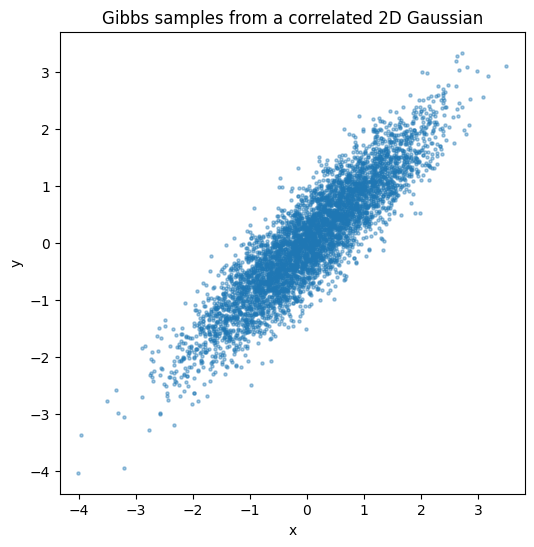

In [2]:
samples = gibbs_sampler_gaussian(n_samples=6000, rho=0.9, burn_in=1000)

plt.figure(figsize=(6, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gibbs samples from a correlated 2D Gaussian")
plt.axis("equal")
plt.show()

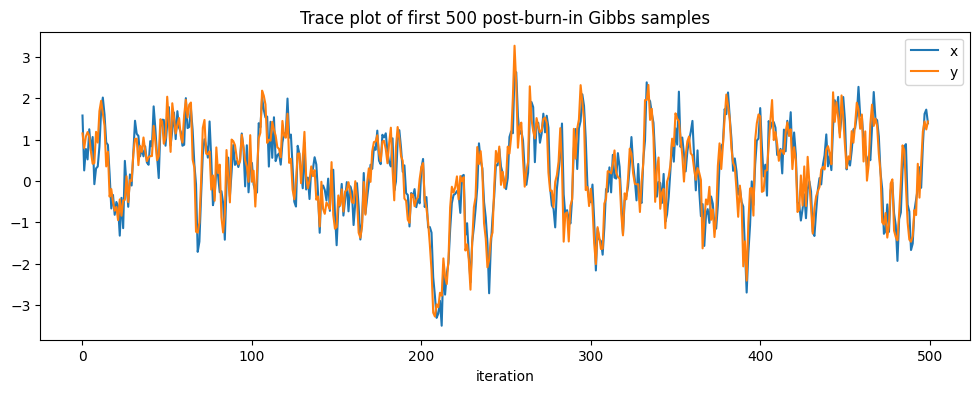

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(samples[:500, 0], label='x')
plt.plot(samples[:500, 1], label='y')
plt.title("Trace plot of first 500 post-burn-in Gibbs samples")
plt.xlabel("iteration")
plt.legend()
plt.show()

## Here is the geometry of how the points were drawn as a Markov Chain

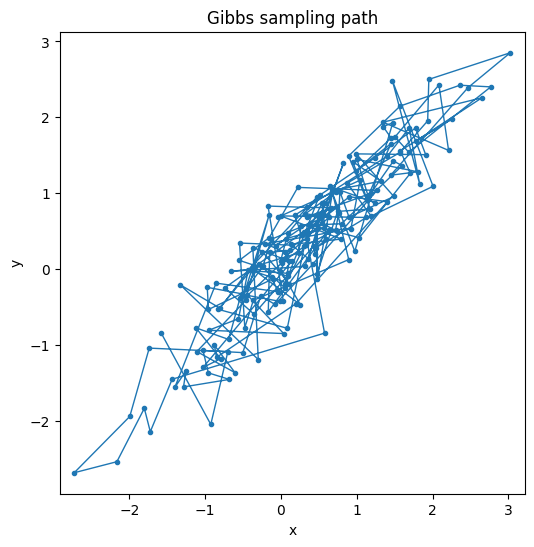

In [4]:
samples_path = gibbs_sampler_gaussian(n_samples=200, rho=0.9, burn_in=0)

plt.figure(figsize=(6, 6))
plt.plot(samples_path[:, 0], samples_path[:, 1], '-o', markersize=3, linewidth=1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gibbs sampling path")
plt.axis("equal")
plt.show()

## Another Method: Metropolis

We want to sample from a probability distribution $\pi(x)$ when:

- Direct sampling is difficult
- The distribution may only be known up to a constant
- We can evaluate the density $ \pi(x) $ (or something proportional to it)

This commonly occurs in Bayesian inference, where:

$$
\pi(\theta \mid D)
\propto
p(D \mid \theta) p(\theta)
$$

and the normalization constant is unknown.

---

## Core Idea

The Metropolis algorithm constructs a **Markov chain** that performs a random walk through the state space. Over time, the chain visits states in proportion to their probability under the target distribution $ \pi(x) $.

At each step:

1. Propose a new state
2. Accept it with some probability
3. Otherwise stay at the current state

This ensures that the long-run distribution of samples matches $ \pi(x) $.

---

## Algorithm

Suppose the current state is:

$$
x_t
$$

### Step 1 — Propose

Draw a candidate state from a proposal distribution:

$$
x'
\sim
q(x' \mid x_t)
$$

A common choice is a Gaussian random walk:

$$
x'
=
x_t
+
\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, \sigma^2)
$$

---

### Step 2 — Compute Acceptance Probability

$$
\alpha
=
\min
\left(
1,
\frac{\pi(x')}{\pi(x_t)}
\right)
$$

This determines how likely we are to move to the proposed state.

---

### Step 3 — Accept or Reject

$$
x_{t+1}
=
\begin{cases}
x' & \text{with probability } \alpha \\
x_t & \text{otherwise}
\end{cases}
$$

So:

- If the new state has **higher probability**, we always accept
- If the new state has **lower probability**, we sometimes accept

This allows the chain to explore the space while still favoring high-probability regions.

In [ ]:
def target(x):
    return np.exp(-x**2 / 2)

def metropolis(n_samples=5000, step_size=1.0):
    samples = []

    x = 0.0

    for _ in range(n_samples):

        # propose
        proposal = x + np.random.normal(0, step_size)

        # acceptance probability
        alpha = min(
            1,
            target(proposal) / target(x)
        )

        # accept / reject
        if np.random.rand() < alpha:
            x = proposal

        samples.append(x)

    return np.array(samples)

## Properties

- Produces dependent samples (a Markov chain)
- Converges to the target distribution under mild conditions
- Does not require gradients
- Works in any dimension

__The generated distribution of samples is below__: these samples mimic $e^{-x^2 / 2}$ which is proportional to the standard normal distribution.

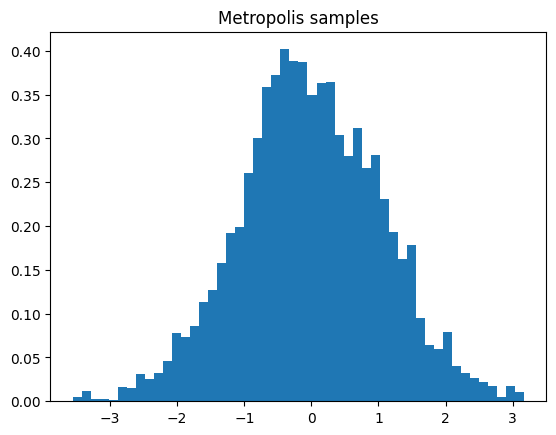

In [6]:
import matplotlib.pyplot as plt

samples = metropolis()

plt.hist(samples, bins=50, density=True)
plt.title("Metropolis samples")
plt.show()

## Acceptance Rate

The fraction of proposed moves that are accepted:

$$
\text{acceptance rate}
=
\frac{\text{accepted moves}}{\text{total proposals}}
$$

Typical good range:

$$
0.2 \; \text{to} \; 0.5
$$